<a href="https://colab.research.google.com/github/spqdot/-Heart-Disease-Prediction-using-Machine-Learning/blob/main/Deep_Learning_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Load the Dataset

In [7]:
import zipfile

with zipfile.ZipFile('/content/archive.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/animals')

print("Dataset extracted!")

Dataset extracted!


In [8]:
import os

print(os.listdir('/content/animals'))

['translate.py', 'raw-img']


In [9]:
print(os.listdir('/content/animals/raw-img'))

['ragno', 'mucca', 'pecora', 'cavallo', 'gallina', 'cane', 'scoiattolo', 'gatto', 'farfalla', 'elefante']


In [10]:
import pandas as pd
import os

dataset_path = '/content/animals/raw-img'

data = []

for label in os.listdir(dataset_path):
    folder = os.path.join(dataset_path, label)

    if os.path.isdir(folder):
        for image in os.listdir(folder):
            image_path = os.path.join(folder, image)
            data.append([image_path, label])

df = pd.DataFrame(data, columns=['image_path', 'label'])

print(df.head())
print("Total images:", len(df))

df.to_csv('animals10.csv', index=False)

                                          image_path  label
0  /content/animals/raw-img/ragno/OIP-tOWUve_gpkI...  ragno
1  /content/animals/raw-img/ragno/OIP-0gV23oVlz3h...  ragno
2  /content/animals/raw-img/ragno/OIP-15dZUn9iemK...  ragno
3  /content/animals/raw-img/ragno/OIP-0eg_5IZeA0b...  ragno
4  /content/animals/raw-img/ragno/OIP-v4DcUeXD77e...  ragno
Total images: 26179


In [11]:
df=pd.read_csv('/content/animals10.csv')
df.head()

,image_path,label
0,/content/animals/raw-img/ragno/OIP-tOWUve_gpkI...,ragno
1,/content/animals/raw-img/ragno/OIP-0gV23oVlz3h...,ragno
2,/content/animals/raw-img/ragno/OIP-15dZUn9iemK...,ragno
3,/content/animals/raw-img/ragno/OIP-0eg_5IZeA0b...,ragno
4,/content/animals/raw-img/ragno/OIP-v4DcUeXD77e...,ragno


In [12]:
df.shape

(26179, 2)

### Data Preprocessing

### Check for missing values

In [13]:
df.isnull().sum()

,0
image_path,0
label,0


### Explore the classes

In [14]:
df['label'].value_counts()

,count
label,
cane,4863
ragno,4821
gallina,3098
cavallo,2623
farfalla,2112
mucca,1866
scoiattolo,1862
pecora,1820
gatto,1668


### Encode the labels

In [15]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['label_encoded'] = le.fit_transform(df['label'])

print(le.classes_)

['cane' 'cavallo' 'elefante' 'farfalla' 'gallina' 'gatto' 'mucca' 'pecora'
 'ragno' 'scoiattolo']


### Split the data

In [16]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

train_df, val_df = train_test_split(
    train_df,
    test_size=0.2,
    random_state=42,
    stratify=train_df['label']
)

In [17]:
train_df.shape, val_df.shape, test_df.shape

((16754, 3), (4189, 3), (5236, 3))

In [18]:
train_df.columns

Index(['image_path', 'label', 'label_encoded'], dtype='object')

In [19]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16754 entries, 15829 to 16260
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   image_path     16754 non-null  object
 1   label          16754 non-null  object
 2   label_encoded  16754 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 523.6+ KB


### Resize images

In [20]:
from PIL import Image

img = Image.open(df['image_path'][0])
print(img.size)

(300, 200)


### Check several images

In [21]:
for i in range(10):
    img = Image.open(df['image_path'][i])
    print(img.size)

(300, 200)
(300, 200)
(201, 300)
(296, 300)
(300, 279)
(300, 200)
(300, 287)
(300, 225)
(200, 300)
(300, 240)


In [23]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    width_shift_range=0.2,
    height_shift_range=0.2
)

In [24]:
test_datagen = ImageDataGenerator(
    rescale=1./255
)

### For Train generator

In [25]:
train_generator = train_datagen.flow_from_dataframe(
    train_df,
    x_col='image_path',
    y_col='label',
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical'
)

Found 16754 validated image filenames belonging to 10 classes.


### Validation generator:

In [26]:
val_generator = test_datagen.flow_from_dataframe(
    val_df,
    x_col='image_path',
    y_col='label',
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 4189 validated image filenames belonging to 10 classes.


### Test generator:

In [27]:
test_generator = test_datagen.flow_from_dataframe(
    test_df,
    x_col='image_path',
    y_col='label',
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 5236 validated image filenames belonging to 10 classes.


### Check the image size

In [28]:
images, labels = next(train_generator)
print(images.shape)
print(labels.shape)

(32, 128, 128, 3)
(32, 10)


### Normalize pixel values

In [31]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True)

In [32]:
test_datagen = ImageDataGenerator(
    rescale=1./255
)

In [36]:
train_images, train_labels = next(train_generator)

print(train_images.min())
print(train_images.max())
print(train_images.shape)

0.0
1.0
(32, 128, 128, 3)


In [34]:
val_images, val_labels = next(val_generator)

print(val_images.min())
print(val_images.max())
print(val_images.shape)

0.0
1.0
(32, 128, 128, 3)


In [35]:
test_images, test_labels = next(test_generator)

print(test_images.min())
print(test_images.max())
print(test_images.shape)

0.0
1.0
(32, 128, 128, 3)


### Create visualizations of some images, and labels.


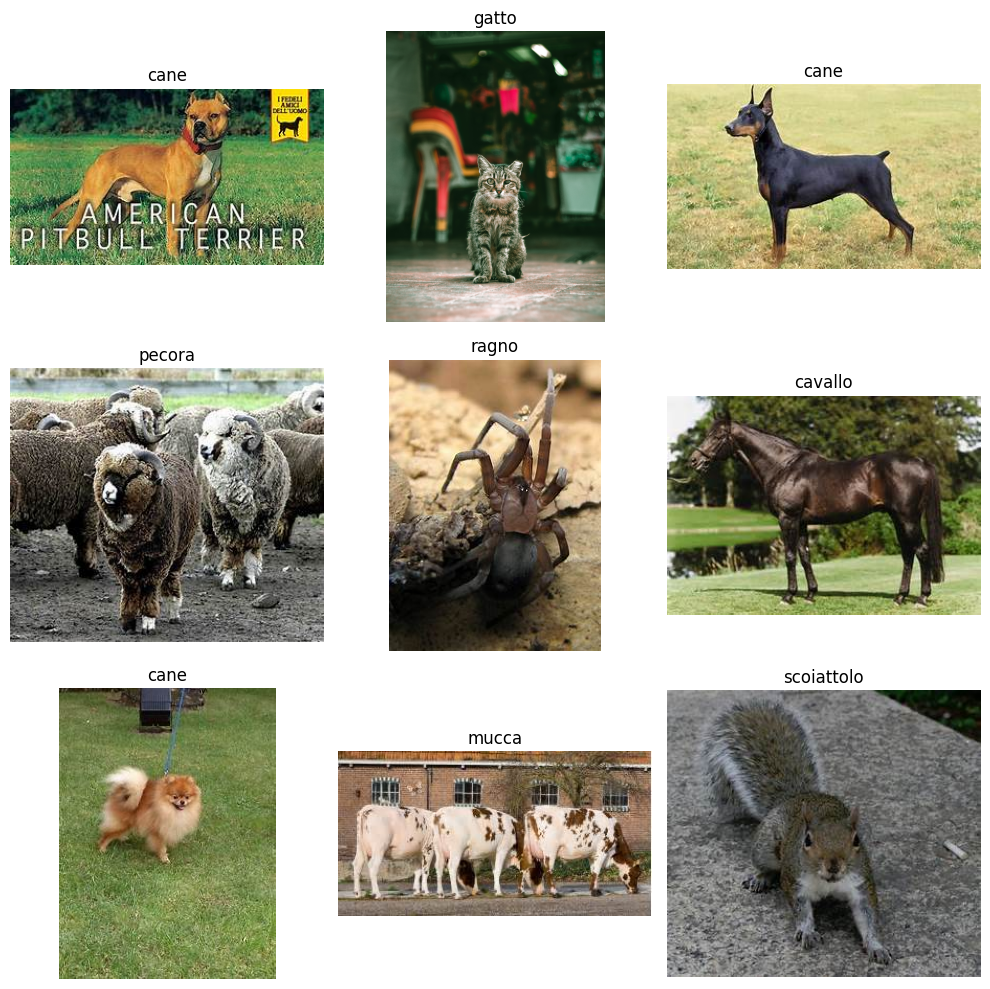

In [37]:
import matplotlib.pyplot as plt
from PIL import Image

fig, axes = plt.subplots(3, 3, figsize=(10, 10))

for i, ax in enumerate(axes.flat):
    img_path = train_df.iloc[i]['image_path']
    label = train_df.iloc[i]['label']

    img = Image.open(img_path)

    ax.imshow(img)
    ax.set_title(label)
    ax.axis('off')

plt.tight_layout()
plt.show()

### after preprocessing (resized and normalized) from the generator:

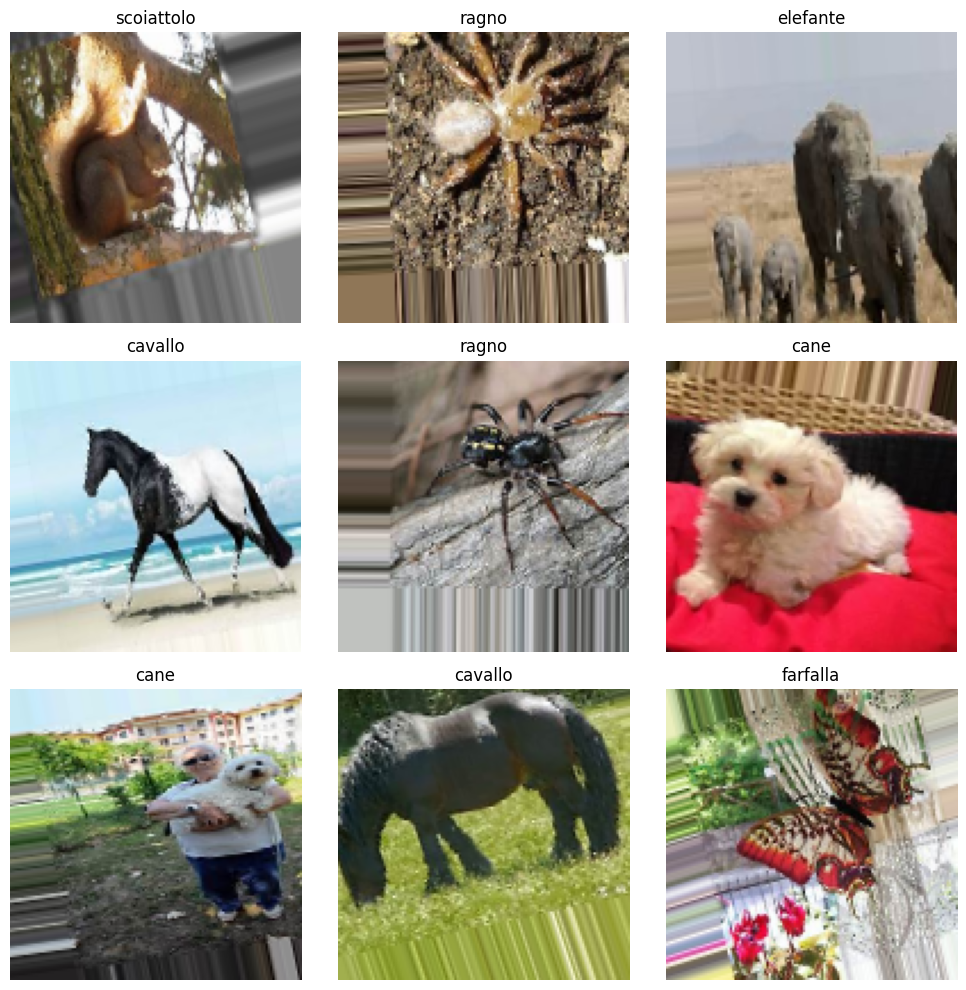

In [39]:
class_names = list(train_generator.class_indices.keys())

fig, axes = plt.subplots(3, 3, figsize=(10, 10))

for i, ax in enumerate(axes.flat):
    ax.imshow(images[i])
    label_index = labels[i].argmax()
    ax.set_title(class_names[label_index])
    ax.axis('off')

plt.tight_layout()
plt.show()